In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

In [21]:
df1=pd.read_parquet('D:/AHU/rdm-wach-ai/paraquet_data/cleaned/raw_data_e0209.parquet',engine="pyarrow")
df1.head(2)

,time,result,table,controller,site,power_factor_avg,units,current_l1,current_l2,current_l3,volts_l1_n,volts_l2_n,volts_l3_n,power_total
0,2025-11-05 09:30:00+00:00,0.0,1.500000,e0209,0.0,0.853333,0.0,13.143333,13.043333,13.436667,235.683333,234.166667,235.816667,7.951223
1,2025-11-05 09:45:00+00:00,0.0,1.517241,e0209,0.0,0.855714,0.0,13.134286,13.042857,13.441429,233.728571,232.000000,233.714286,7.911959


In [22]:
df1

,time,result,table,controller,site,power_factor_avg,units,current_l1,current_l2,current_l3,volts_l1_n,volts_l2_n,volts_l3_n,power_total
0,2025-11-05 09:30:00+00:00,0.0,1.500000,e0209,0.0,0.853333,0.0,13.143333,13.043333,13.436667,235.683333,234.166667,235.816667,7.951223
1,2025-11-05 09:45:00+00:00,0.0,1.517241,e0209,0.0,0.855714,0.0,13.134286,13.042857,13.441429,233.728571,232.000000,233.714286,7.911959
2,2025-11-05 10:00:00+00:00,0.0,1.482759,e0209,0.0,0.860000,0.0,13.181429,13.094286,13.510000,232.100000,230.328571,232.042857,7.913114
3,2025-11-05 10:15:00+00:00,0.0,1.514286,e0209,0.0,0.860000,0.0,13.137500,13.067500,13.491250,232.362500,230.662500,232.412500,7.926006
4,2025-11-05 10:30:00+00:00,0.0,1.500000,e0209,0.0,0.860000,0.0,13.122857,13.047143,13.472857,232.371429,230.671429,232.485714,7.891433
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9461,2026-02-11 22:45:00+00:00,0.0,1.529412,e0209,0.0,0.850000,0.0,12.622500,12.807500,12.895000,233.975000,231.925000,234.700000,7.628153
9462,2026-02-11 23:00:00+00:00,0.0,1.500000,e0209,0.0,0.850000,0.0,12.487500,12.665000,12.742500,233.675000,231.750000,234.475000,7.571892
9463,2026-02-11 23:15:00+00:00,0.0,1.500000,e0209,0.0,0.850000,0.0,12.496667,12.686667,12.766667,234.000000,232.000000,234.766667,7.576010
9464,2026-02-11 23:30:00+00:00,0.0,1.500000,e0209,0.0,0.850000,0.0,12.530000,12.650000,12.595000,232.300000,230.425000,232.625000,7.474603


In [23]:
numeric_cols = df1.select_dtypes(include='number').columns
df_numeric = df1[numeric_cols]
df_numeric

,result,table,site,power_factor_avg,units,current_l1,current_l2,current_l3,volts_l1_n,volts_l2_n,volts_l3_n,power_total
0,0.0,1.500000,0.0,0.853333,0.0,13.143333,13.043333,13.436667,235.683333,234.166667,235.816667,7.951223
1,0.0,1.517241,0.0,0.855714,0.0,13.134286,13.042857,13.441429,233.728571,232.000000,233.714286,7.911959
2,0.0,1.482759,0.0,0.860000,0.0,13.181429,13.094286,13.510000,232.100000,230.328571,232.042857,7.913114
3,0.0,1.514286,0.0,0.860000,0.0,13.137500,13.067500,13.491250,232.362500,230.662500,232.412500,7.926006
4,0.0,1.500000,0.0,0.860000,0.0,13.122857,13.047143,13.472857,232.371429,230.671429,232.485714,7.891433
...,...,...,...,...,...,...,...,...,...,...,...,...
9461,0.0,1.529412,0.0,0.850000,0.0,12.622500,12.807500,12.895000,233.975000,231.925000,234.700000,7.628153
9462,0.0,1.500000,0.0,0.850000,0.0,12.487500,12.665000,12.742500,233.675000,231.750000,234.475000,7.571892
9463,0.0,1.500000,0.0,0.850000,0.0,12.496667,12.686667,12.766667,234.000000,232.000000,234.766667,7.576010
9464,0.0,1.500000,0.0,0.850000,0.0,12.530000,12.650000,12.595000,232.300000,230.425000,232.625000,7.474603


Feature engineering

In [24]:
#Average current
df1['current_avg'] = (
    df1['current_l1'] +
    df1['current_l2'] +
    df1['current_l3']
) / 3

#Average Voltage
df1['voltage_avg'] = (
    df1['volts_l1_n'] +
    df1['volts_l2_n'] +
    df1['volts_l3_n']
) / 3

#apparent power
df1['apparent_power'] = (
    
    np.sqrt(3) *
    df1['voltage_avg'] *
    df1['current_avg']
) / 1000

#estimated real power
df1['estimated_power'] = df1['apparent_power'] * df1['power_factor_avg']




In [25]:
#drop unwanted columns
drop_cols = ['result', 'controller', 'units','table','site','power_l1','power_l2','power_l3',
'apparent_power_total'
]
df_corr = df1.drop(columns=drop_cols, errors='ignore')
df=df_corr.copy()

In [26]:
df.columns

Index(['time', 'power_factor_avg', 'current_l1', 'current_l2', 'current_l3',
       'volts_l1_n', 'volts_l2_n', 'volts_l3_n', 'power_total', 'current_avg',
       'voltage_avg', 'apparent_power', 'estimated_power'],
      dtype='object')

In [27]:
df=df_corr.copy()
df.index=pd.to_datetime(df.index)

df = df.reset_index()

df["hour"] = df["time"].dt.hour
df["dayofweek"] = df["time"].dt.dayofweek
df["month"] = df["time"].dt.month
df["is_weekend"] = df["dayofweek"].isin([5,6]).astype(int)

#helps model understand daily cycle smoothly-reduce MaPE
df['sin_hour'] = np.sin(2*np.pi*df['hour']/24)
df['cos_hour'] = np.cos(2*np.pi*df['hour']/24)



In [28]:
#lag features (15-min interval)  # 1 step, 1 hour, 1 day lag
for lag in [1]:
    df[f'lag_{lag}']=df['power_total'].shift(lag)

In [29]:
df["rolling_mean_4"] = df["power_total"].shift(1).rolling(3).mean()
df["rolling_std_4"] = df["power_total"].shift(1).rolling(3).std()


In [30]:
#outliers increase mape dramatically
df = df[df['power_total'] < df['power_total'].quantile(0.99)]


In [31]:
#Drop Nans after lagging
df=df.dropna()
df=df.drop(columns=['time'])

In [32]:
target_col="power_total"
feature_cols=df.drop(columns=["power_total","index"]).columns

In [33]:
feature_cols

Index(['power_factor_avg', 'current_l1', 'current_l2', 'current_l3',
       'volts_l1_n', 'volts_l2_n', 'volts_l3_n', 'current_avg', 'voltage_avg',
       'apparent_power', 'estimated_power', 'hour', 'dayofweek', 'month',
       'is_weekend', 'sin_hour', 'cos_hour', 'lag_1', 'rolling_mean_4',
       'rolling_std_4'],
      dtype='object')

In [34]:
# 4. Rolling window parameters
rows_per_day = 96      # 15-minute intervals
train_days = 60
test_days = 7
train_size = train_days * rows_per_day
test_size = test_days * rows_per_day

r2_scores = []

In [35]:
# Rolling window parameters
rows_per_day = 96
train_days = 60
test_days = 7

train_size = train_days * rows_per_day
test_size = test_days * rows_per_day

# Metric storage
mae_scores = []
rmse_scores = []
mape_scores = []
r2_scores = []

for start in range(0, len(df) - train_size - test_size + 1, test_size):

    train_idx = slice(start, start + train_size)
    test_idx = slice(start + train_size, start + train_size + test_size)

    X_train = df.iloc[train_idx][feature_cols]
    y_train = df.iloc[train_idx][target_col]

    X_test = df.iloc[test_idx][feature_cols]
    y_test = df.iloc[test_idx][target_col]

    model = xgb.XGBRegressor(
        n_estimators=600,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='reg:squarederror',
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # ---- METRICS ----
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Safe MAPE (avoid divide by zero)
    mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100

    # Store
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)
    mape_scores.append(mape)
print("\nRolling Window Backtesting Results")
print("-"*50)
print(f"Number of splits: {len(r2_scores)}")

print("\nAverage Metrics Across All Splits")
print(f"Mean MAE  : {np.mean(mae_scores):.4f}")
print(f"Mean RMSE : {np.mean(rmse_scores):.4f}")
print(f"Mean MAPE : {np.mean(mape_scores):.2f}%")
print(f"Mean R²   : {np.mean(r2_scores):.4f}")

print("\nStandard Deviation of Metrics")
print(f"Std MAE   : {np.std(mae_scores):.4f}")
print(f"Std RMSE  : {np.std(rmse_scores):.4f}")
print(f"Std MAPE  : {np.std(mape_scores):.2f}%")
print(f"Std R²    : {np.std(r2_scores):.4f}")
print("\nSplit-wise Results")
print("-"*50)

for i in range(len(r2_scores)):
    print(f"Split {i+1}: "
          f"MAE={mae_scores[i]:.4f}, "
          f"RMSE={rmse_scores[i]:.4f}, "
          f"MAPE={mape_scores[i]:.2f}%, "
          f"R²={r2_scores[i]:.4f}")



Rolling Window Backtesting Results
--------------------------------------------------
Number of splits: 5

Average Metrics Across All Splits
Mean MAE  : 0.0220
Mean RMSE : 0.0811
Mean MAPE : 1.54%
Mean R²   : 0.8906

Standard Deviation of Metrics
Std MAE   : 0.0061
Std RMSE  : 0.0694
Std MAPE  : 2.51%
Std R²    : 0.0512

Split-wise Results
--------------------------------------------------
Split 1: MAE=0.0146, RMSE=0.0183, MAPE=0.19%, R²=0.9428
Split 2: MAE=0.0300, RMSE=0.2098, MAPE=6.57%, R²=0.8281
Split 3: MAE=0.0177, RMSE=0.0513, MAPE=0.24%, R²=0.8292
Split 4: MAE=0.0284, RMSE=0.0952, MAPE=0.47%, R²=0.9178
Split 5: MAE=0.0195, RMSE=0.0310, MAPE=0.25%, R²=0.9351


In [36]:
print(y_test.describe())


count    672.000000
mean       7.725302
std        0.121637
min        7.417120
25%        7.644144
50%        7.727732
75%        7.801589
max        7.989407
Name: power_total, dtype: float64


In [37]:
y_test

8546    7.838926
8547    7.830871
8548    7.839070
8549    7.901697
8550    7.751071
          ...   
9213    7.656217
9214    7.759548
9215    7.769529
9216    7.757352
9217    7.692107
Name: power_total, Length: 672, dtype: float64

In [38]:
# print(df.dtypes)

feature importance


Rolling Window Backtesting Results
--------------------------------------------------
Number of splits: 5

Average Metrics Across All Splits
Mean MAE  : 0.0220
Mean RMSE : 0.0811
Mean MAPE : 1.54%
Mean R²   : 0.8906

Standard Deviation of Metrics
Std MAE   : 0.0061
Std RMSE  : 0.0694
Std MAPE  : 2.51%
Std R²    : 0.0512

Split-wise Results
--------------------------------------------------
Split 1: MAE=0.0146, RMSE=0.0183, MAPE=0.19%, R²=0.9428
Split 2: MAE=0.0300, RMSE=0.2098, MAPE=6.57%, R²=0.8281
Split 3: MAE=0.0177, RMSE=0.0513, MAPE=0.24%, R²=0.8292
Split 4: MAE=0.0284, RMSE=0.0952, MAPE=0.47%, R²=0.9178
Split 5: MAE=0.0195, RMSE=0.0310, MAPE=0.25%, R²=0.9351

Top 15 Important Features
--------------------------------------------------
             Feature  Importance
0   power_factor_avg    0.385460
9     apparent_power    0.206484
10   estimated_power    0.181969
3         current_l3    0.118190
7        current_avg    0.079375
1         current_l1    0.010418
2         current

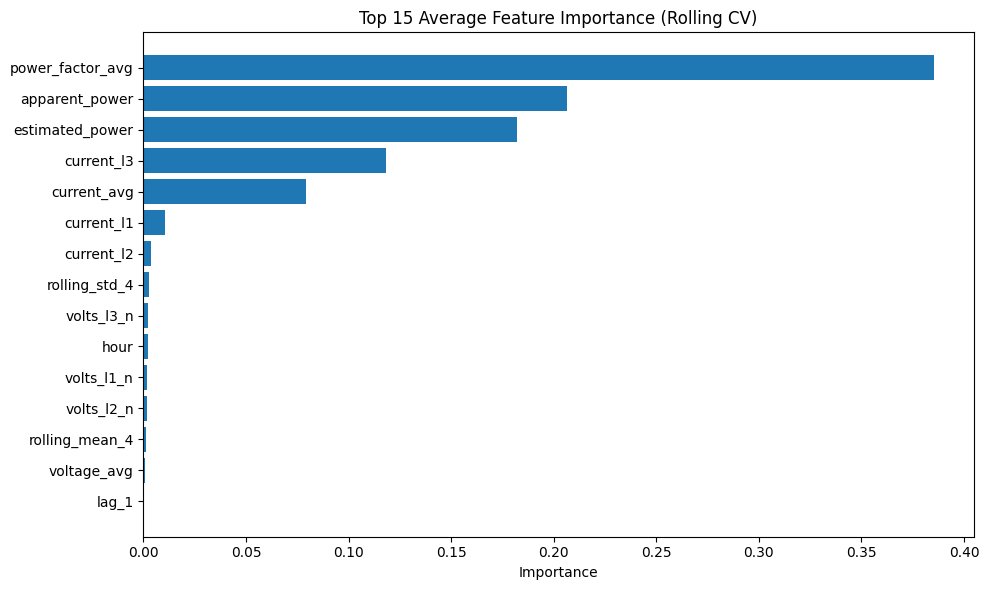

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Rolling window parameters
rows_per_day = 96
train_days = 60
test_days = 7

train_size = train_days * rows_per_day
test_size = test_days * rows_per_day

# Metric storage
mae_scores = []
rmse_scores = []
mape_scores = []
r2_scores = []

#  Feature importance storage
feature_importance_list = []

for start in range(0, len(df) - train_size - test_size + 1, test_size):

    train_idx = slice(start, start + train_size)
    test_idx = slice(start + train_size, start + train_size + test_size)

    X_train = df.iloc[train_idx][feature_cols]
    y_train = df.iloc[train_idx][target_col]

    X_test = df.iloc[test_idx][feature_cols]
    y_test = df.iloc[test_idx][target_col]

    model = xgb.XGBRegressor(
        n_estimators=600,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='reg:squarederror',
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # ---- METRICS ----
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)
    mape_scores.append(mape)

    #  STORE FEATURE IMPORTANCE
    feature_importance_list.append(model.feature_importances_)

# ==============================
# RESULTS SUMMARY
# ==============================

print("\nRolling Window Backtesting Results")
print("-"*50)
print(f"Number of splits: {len(r2_scores)}")

print("\nAverage Metrics Across All Splits")
print(f"Mean MAE  : {np.mean(mae_scores):.4f}")
print(f"Mean RMSE : {np.mean(rmse_scores):.4f}")
print(f"Mean MAPE : {np.mean(mape_scores):.2f}%")
print(f"Mean R²   : {np.mean(r2_scores):.4f}")

print("\nStandard Deviation of Metrics")
print(f"Std MAE   : {np.std(mae_scores):.4f}")
print(f"Std RMSE  : {np.std(rmse_scores):.4f}")
print(f"Std MAPE  : {np.std(mape_scores):.2f}%")
print(f"Std R²    : {np.std(r2_scores):.4f}")

print("\nSplit-wise Results")
print("-"*50)

for i in range(len(r2_scores)):
    print(f"Split {i+1}: "
          f"MAE={mae_scores[i]:.4f}, "
          f"RMSE={rmse_scores[i]:.4f}, "
          f"MAPE={mape_scores[i]:.2f}%, "
          f"R²={r2_scores[i]:.4f}")

# ==============================
#  AVERAGE FEATURE IMPORTANCE
# ==============================

avg_importance = np.mean(feature_importance_list, axis=0)

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": avg_importance
}).sort_values(by="Importance", ascending=False)

print("\nTop 15 Important Features")
print("-"*50)
print(importance_df.head(15))

# ==============================
#  PLOT FEATURE IMPORTANCE
# ==============================

plt.figure(figsize=(10,6))
plt.barh(
    importance_df["Feature"][:15][::-1],
    importance_df["Importance"][:15][::-1]
)
plt.title("Top 15 Average Feature Importance (Rolling CV)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [41]:
import mlflow
import mlflow.xgboost  # if you want XGBoost-specific logging
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set experiment name
mlflow.set_experiment("Energy_Model_Tracking")

2026/02/20 13:21:19 INFO mlflow.tracking.fluent: Experiment with name 'Energy_Model_Tracking' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///d:/AHU/rdm-wach-ai/paraquet_data/new_notebook/mlruns/999163681381159645', creation_time=1771572979247, experiment_id='999163681381159645', last_update_time=1771572979247, lifecycle_stage='active', name='Energy_Model_Tracking', tags={}>

Logging Parameters, Metrics, and Model

In [44]:


# Model
model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    objective='reg:squarederror',
    random_state=42
)

# Start MLflow run
with mlflow.start_run(run_name="XGBoost_Run1"):
    
    # Log model parameters
    mlflow.log_param("n_estimators", model.n_estimators)
    mlflow.log_param("max_depth", model.max_depth)
    mlflow.log_param("learning_rate", model.learning_rate)

    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Log metrics
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2", r2)
    
    # Log model
    mlflow.xgboost.log_model(model, "xgb_model")
    
    print(f"MAE: {mae}, RMSE: {rmse}, R2: {r2}")

2026/02/20 13:22:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
d:\AHU\rdm-wach-ai\venv\lib\site-packages\xgboost\core.py:158: UserWarning: [13:22:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)
2026/02/20 13:23:20 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


MAE: 0.020028792125082715, RMSE: 0.0020762962707368887, R2: 0.8594590104791044
